Исследование датасета Dataset_22022022

In [65]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from artifact_loader import original_data_path

In [61]:
Path.cwd().name == "notebooks"

True

In [66]:
df_cbarq = pd.read_csv(original_data_path())

In [4]:
new_columns = [
    # --- demographics & service (16) ---
    "dog_age_years", "dog_age_months", "breed", "breed_other", "dog_sex",
    "neutered_spayed", "age_at_adoption_years", "age_at_adoption_months",
    "owner_sex", "owner_age", "owner_profession", "owner_profession_other",
    "other_dogs_present", "other_dogs_by_age", "other_dogs_by_age_a", "other_dogs_by_age_b",
    # --- aggression Q1–Q35 ---
    *[f"question_{i:03d}" for i in range(1, 36)],
    "other_aggression_present", "other_aggression_describe",
    # --- fear Q36–Q53 ---
    *[f"question_{i:03d}" for i in range(36, 54)],
    # --- separation Q54–Q61 ---
    *[f"question_{i:03d}" for i in range(54, 62)],
    "other_fear_present", "other_fear_describe",
    # --- excitability Q62–Q67 ---
    *[f"question_{i:03d}" for i in range(62, 68)],
    "other_excitability_present", "other_excitability_describe",
    # --- attachment + miscellaneous Q68–Q100 ---
    *[f"question_{i:03d}" for i in range(68, 101)],
    "other_bizarre_behavior_describe",
]

assert len(new_columns) == df_cbarq.shape[1], (len(new_columns), df_cbarq.shape[1])
df_cbarq.columns = new_columns

In [5]:
na_counts = df_cbarq.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)

breed_other                        791
other_bizarre_behavior_describe    730
other_aggression_describe          695
owner_profession_other             695
other_excitability_describe        682
other_fear_describe                676
other_dogs_by_age_a                546
other_dogs_by_age                  545
other_dogs_by_age_b                544
question_035                       541
question_034                       541
question_033                       541
question_032                       541
age_at_adoption_years               29
age_at_adoption_months              29
dog_age_years                        3
dog_age_months                       3
owner_profession                     3
owner_age                            3
owner_sex                            3
neutered_spayed                      3
dog_sex                              3
breed                                3
other_dogs_present                   3
dtype: int64

In [6]:
df_cbarq_original = pd.read_csv(PATHS["original_data"])

In [7]:
df_cbarq[df_cbarq['breed'].isna()]

,dog_age_years,dog_age_months,breed,breed_other,dog_sex,neutered_spayed,age_at_adoption_years,age_at_adoption_months,owner_sex,owner_age,...,question_092,question_093,question_094,question_095,question_096,question_097,question_098,question_099,question_100,other_bizarre_behavior_describe
803,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN
804,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,803,803,803,803,803,803,803,803,803,NaN
805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,NaN


In [8]:
df_cbarq.dropna(subset=['breed'], inplace=True)

In [9]:
na_counts = df_cbarq.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)

breed_other                        788
other_bizarre_behavior_describe    727
other_aggression_describe          695
owner_profession_other             692
other_excitability_describe        682
other_fear_describe                676
other_dogs_by_age_a                543
other_dogs_by_age                  542
other_dogs_by_age_b                541
question_032                       541
question_033                       541
question_034                       541
question_035                       541
age_at_adoption_years               26
age_at_adoption_months              26
dtype: int64

In [10]:
df_cbarq.drop(columns=['breed_other',
'other_bizarre_behavior_describe',
'other_aggression_describe',
'owner_profession_other',
'other_excitability_describe',
'other_fear_describe',
'other_dogs_by_age_a',
'other_dogs_by_age',
'other_dogs_by_age_b',
'question_032',
'question_033',
'question_034',
'question_035'], inplace=True)

In [11]:
na_counts = df_cbarq.isna().sum()
na_counts[na_counts > 0].sort_values(ascending=False)

age_at_adoption_years     26
age_at_adoption_months    26
dtype: int64

In [12]:
df_cbarq['age_at_adoption_years'].value_counts()

age_at_adoption_years
0.0     680
1.0      33
2.0      19
4.0      11
3.0       9
5.0       6
7.0       5
8.0       5
6.0       5
10.0      1
9.0       1
11.0      1
13.0      1
Name: count, dtype: int64

In [13]:
df_cbarq.loc[df_cbarq['age_at_adoption_years'].isna(), 'age_at_adoption_years'] = 0

In [14]:
df_cbarq['age_at_adoption_months'] = (
    df_cbarq['age_at_adoption_months']
    .str.replace(',', '.', regex=False)
    .astype('float')
)
df_cbarq.loc[df_cbarq['age_at_adoption_months'].isna(), 'age_at_adoption_months'] = 0
df_cbarq = df_cbarq.astype({'age_at_adoption_years': 'int32', 'age_at_adoption_months': 'int32'})

In [15]:
# 999
# диапазон ответов на вопросы

df_cbarq.describe()
for i in range(1,101):
    try:
        print(df_cbarq[f'question_{i:03d}'].value_counts())
    except:
        print(f'question_{i:03d} error')

for i in range(1,101):
    try:
        df_cbarq.loc[df_cbarq['question_{i:03d}'] == 999, 'question_{i:03d}'] = None
    except:
        print(f'question_{i:03d} error')
for i in range(1,101):
    try:
        df_cbarq.dropna(subset=['question_{i:03d}'], inplace=True)
    except:
        print(f'question_{i:03d} error')



question_001
1      343
0      276
2      106
999     29
3       27
4       22
Name: count, dtype: int64
question_002
0      344
1      321
2       66
4       31
3       21
999     20
Name: count, dtype: int64
question_003
1      308
0      154
2      147
4       68
3       68
999     58
Name: count, dtype: int64
question_004
0      425
1      288
2       80
3        8
4        1
999      1
Name: count, dtype: int64
question_005
2      262
1      185
3      142
0       97
4       84
999     33
Name: count, dtype: int64
question_006
1      255
0      217
2      202
999     58
3       49
4       22
Name: count, dtype: int64
question_007
2      313
3      196
4      171
1       98
0       22
999      3
Name: count, dtype: int64
question_008
0      228
1      178
2      153
4      138
3      103
999      3
Name: count, dtype: int64
question_009
0      698
1       58
2       35
3        5
999      4
4        3
Name: count, dtype: int64
question_010
0      579
1      115
2       85
3       1

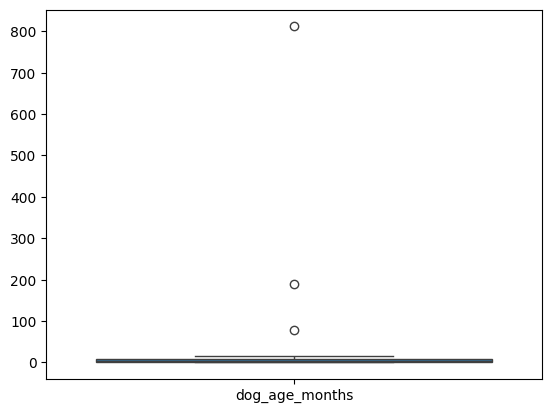

,dog_age_months,dog_age_years
171,13.0,1.0
368,15.0,15.0
401,190.0,15.0
432,77.0,6.0
537,13.0,1.0
772,812.0,6.0


,dog_age_months,dog_age_years
6,4.0,1.0
12,6.0,1.0
41,6.0,1.0
43,0.0,1.0
47,9.0,1.0
...,...,...
761,3.0,1.0
766,3.0,1.0
770,11.0,1.0
787,2.0,1.0


In [16]:
# выбросы по возрасту
sns.boxplot(data=df_cbarq[['dog_age_months']])
plt.show()
display(df_cbarq[df_cbarq['dog_age_months'] > 12][['dog_age_months', 'dog_age_years']])
display(df_cbarq[df_cbarq['dog_age_years'] == 1][['dog_age_months', 'dog_age_years']])




In [ ]:
df_cbarq.drop(list(df_cbarq[df_cbarq['dog_age_months'] == 15].index), inplace=True)

In [56]:
df_cbarq.loc[list(df_cbarq[df_cbarq['dog_age_months'] > 12].index), 'dog_age_months'] = df_cbarq['dog_age_months'] % 12

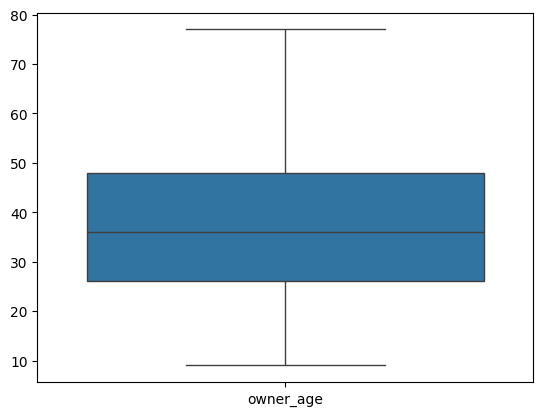

In [57]:
# выбросы по возрасту владельца
sns.boxplot(data=df_cbarq[['owner_age']])
plt.show()


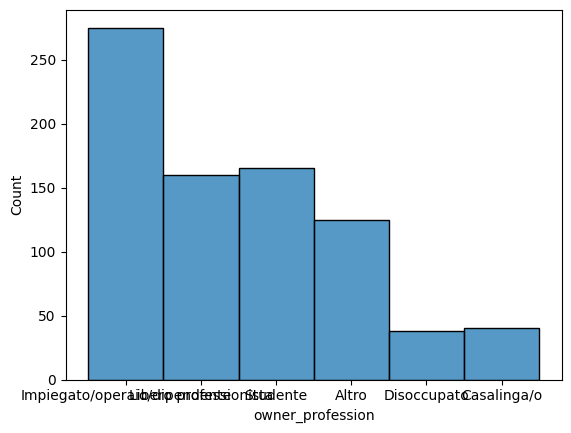

In [19]:
# выбросы по профессии владельца
sns.histplot(data=df_cbarq['owner_profession'], )
plt.show()

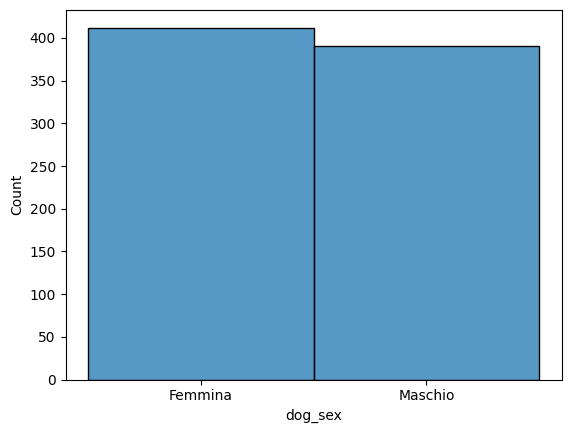

In [20]:
sns.histplot(data=df_cbarq['dog_sex'], )
plt.show()

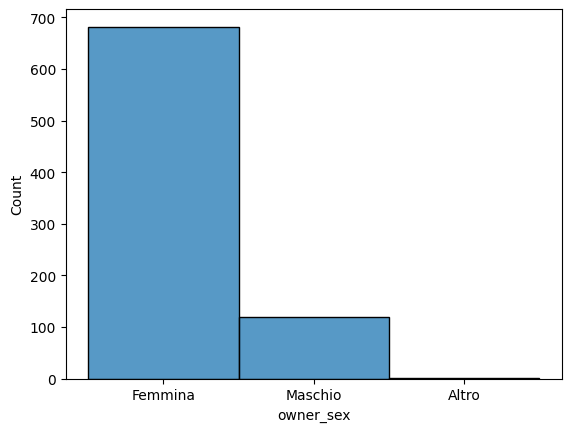

In [21]:
sns.histplot(data=df_cbarq['owner_sex'])
plt.show()

In [22]:
df_cbarq.drop(columns=['owner_sex'], inplace=True)

In [58]:
display(df_cbarq[['dog_age_years',
 'dog_age_months',
 'breed',
 'dog_sex',
 'neutered_spayed',
 'age_at_adoption_years',
 'age_at_adoption_months',
 'owner_age',
 'owner_profession',
 'other_dogs_present', 
 'other_aggression_present', 
 'other_fear_present', 
 'other_excitability_present']].head())


df_cbarq['breed'].value_counts()

,dog_age_years,dog_age_months,breed,dog_sex,neutered_spayed,age_at_adoption_years,age_at_adoption_months,owner_age,owner_profession,other_dogs_present,other_aggression_present,other_fear_present,other_excitability_present
0,2,2,JACK RUSSEL TERRIER,Femmina,0,0,8,42,Impiegato/operaio/dipendente,0,0,0,0
1,12,8,BASSOTTO TEDESCO STANDARD A PELO CORTO,Maschio,1,0,3,44,Libero professionista,1,0,0,0
2,6,3,PINSCHER,Maschio,0,0,3,47,Libero professionista,0,1,1,0
3,4,0,BASSOTTO TEDESCO KANINCHEN A PELO CORTO,Femmina,1,0,3,31,Impiegato/operaio/dipendente,0,0,0,0
4,7,10,INCROCIO / METICCIO,Femmina,1,0,2,32,Impiegato/operaio/dipendente,0,0,1,1


breed
INCROCIO / METICCIO                 308
LABRADOR RETRIEVER                   84
GOLDEN RETRIEVER                     34
BORDER COLLIE                        29
JACK RUSSEL TERRIER                  21
                                   ... 
BLOODHOUND/CHIEN DE SAINT-HUBERT      1
BICHON A POIL FRISE                   1
EPAGNEUL BRETON                       1
SETTER IRLANDESE                      1
GRIFFON BLEU DE GASCOGNE              1
Name: count, Length: 86, dtype: int64

In [24]:
df_cbarq = df_cbarq.astype({'dog_age_years': 'int', 'dog_age_months': 'int', 'neutered_spayed': 'int', 'owner_age': 'int', 'other_dogs_present': 'int'})
df_cbarq['neutered_spayed'].dtype

dtype('int64')

In [25]:
df_cbarq_encoded = pd.get_dummies(df_cbarq, columns=['dog_sex'], dtype=int)
df_cbarq_encoded['neutered_spayed'].dtype

dtype('int64')

In [26]:
df_cbarq_encoded['neutered_spayed'].value_counts()

neutered_spayed
0      406
1      394
999      3
Name: count, dtype: int64

In [27]:
df_cbarq_encoded.loc[df_cbarq_encoded['neutered_spayed'] == 999, 'neutered_spayed'] = None
df_cbarq_encoded.dropna(subset=['neutered_spayed'], inplace=True)
df_cbarq_encoded['neutered_spayed'] = df_cbarq_encoded['neutered_spayed'].astype('int')

# выбросы по количеству собак по возрасту и полу
# выбросы по количеству собак по возрасту и полу и породе

In [28]:
df_cbarq_encoded['neutered_spayed'].dtype

dtype('int64')

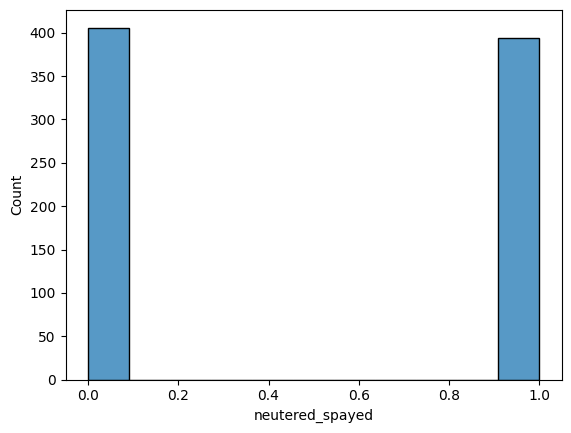

In [29]:
sns.histplot(data=df_cbarq_encoded['neutered_spayed'])
plt.show()

In [30]:
# age_at_adoption_years',
#  'age_at_adoption_months'
df_cbarq_encoded[['age_at_adoption_months']].value_counts()
df_cbarq_encoded.loc[df_cbarq_encoded['age_at_adoption_years'] > df_cbarq_encoded['dog_age_years']].value_counts()



Series([], Name: count, dtype: int64)

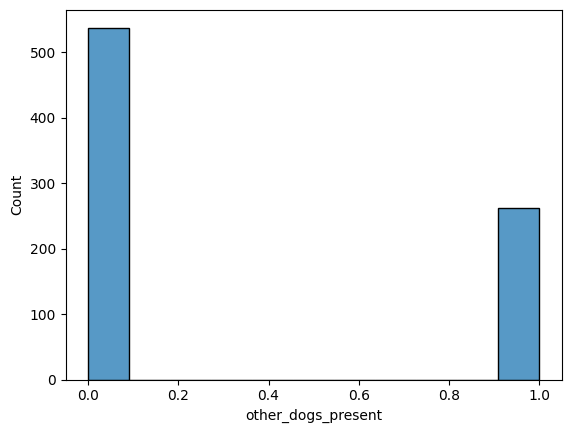

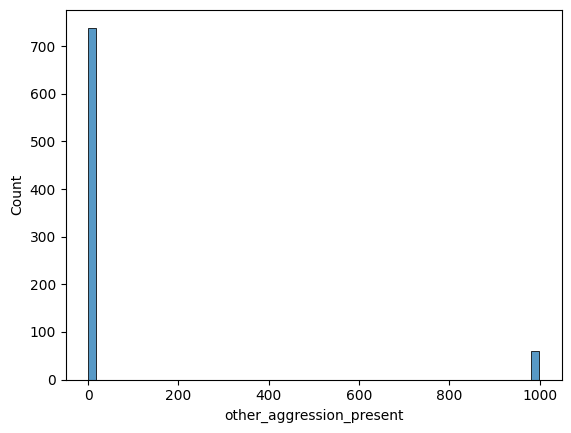

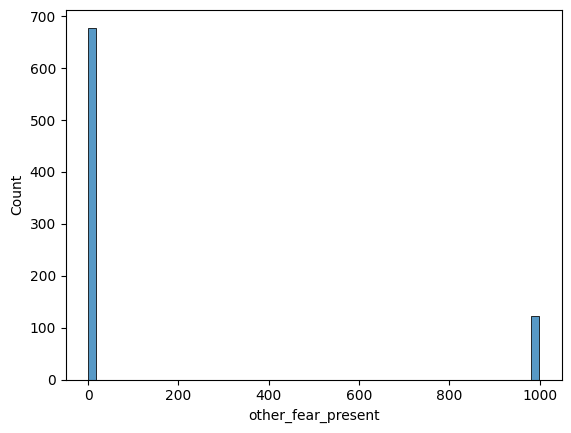

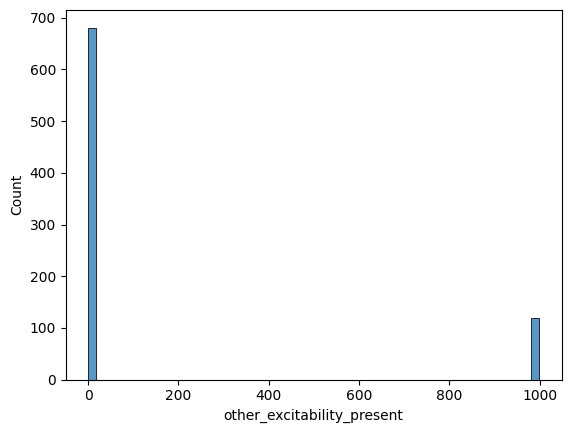

In [31]:
# other_dogs_present', 
#  'other_aggression_present', 
#  'other_fear_present', 
#  'other_excitability_present
sns.histplot(data=df_cbarq_encoded['other_dogs_present'])
plt.show()
sns.histplot(data=df_cbarq_encoded['other_aggression_present'])
plt.show()
sns.histplot(data=df_cbarq_encoded['other_fear_present'])
plt.show()
sns.histplot(data=df_cbarq_encoded['other_excitability_present'])
plt.show()

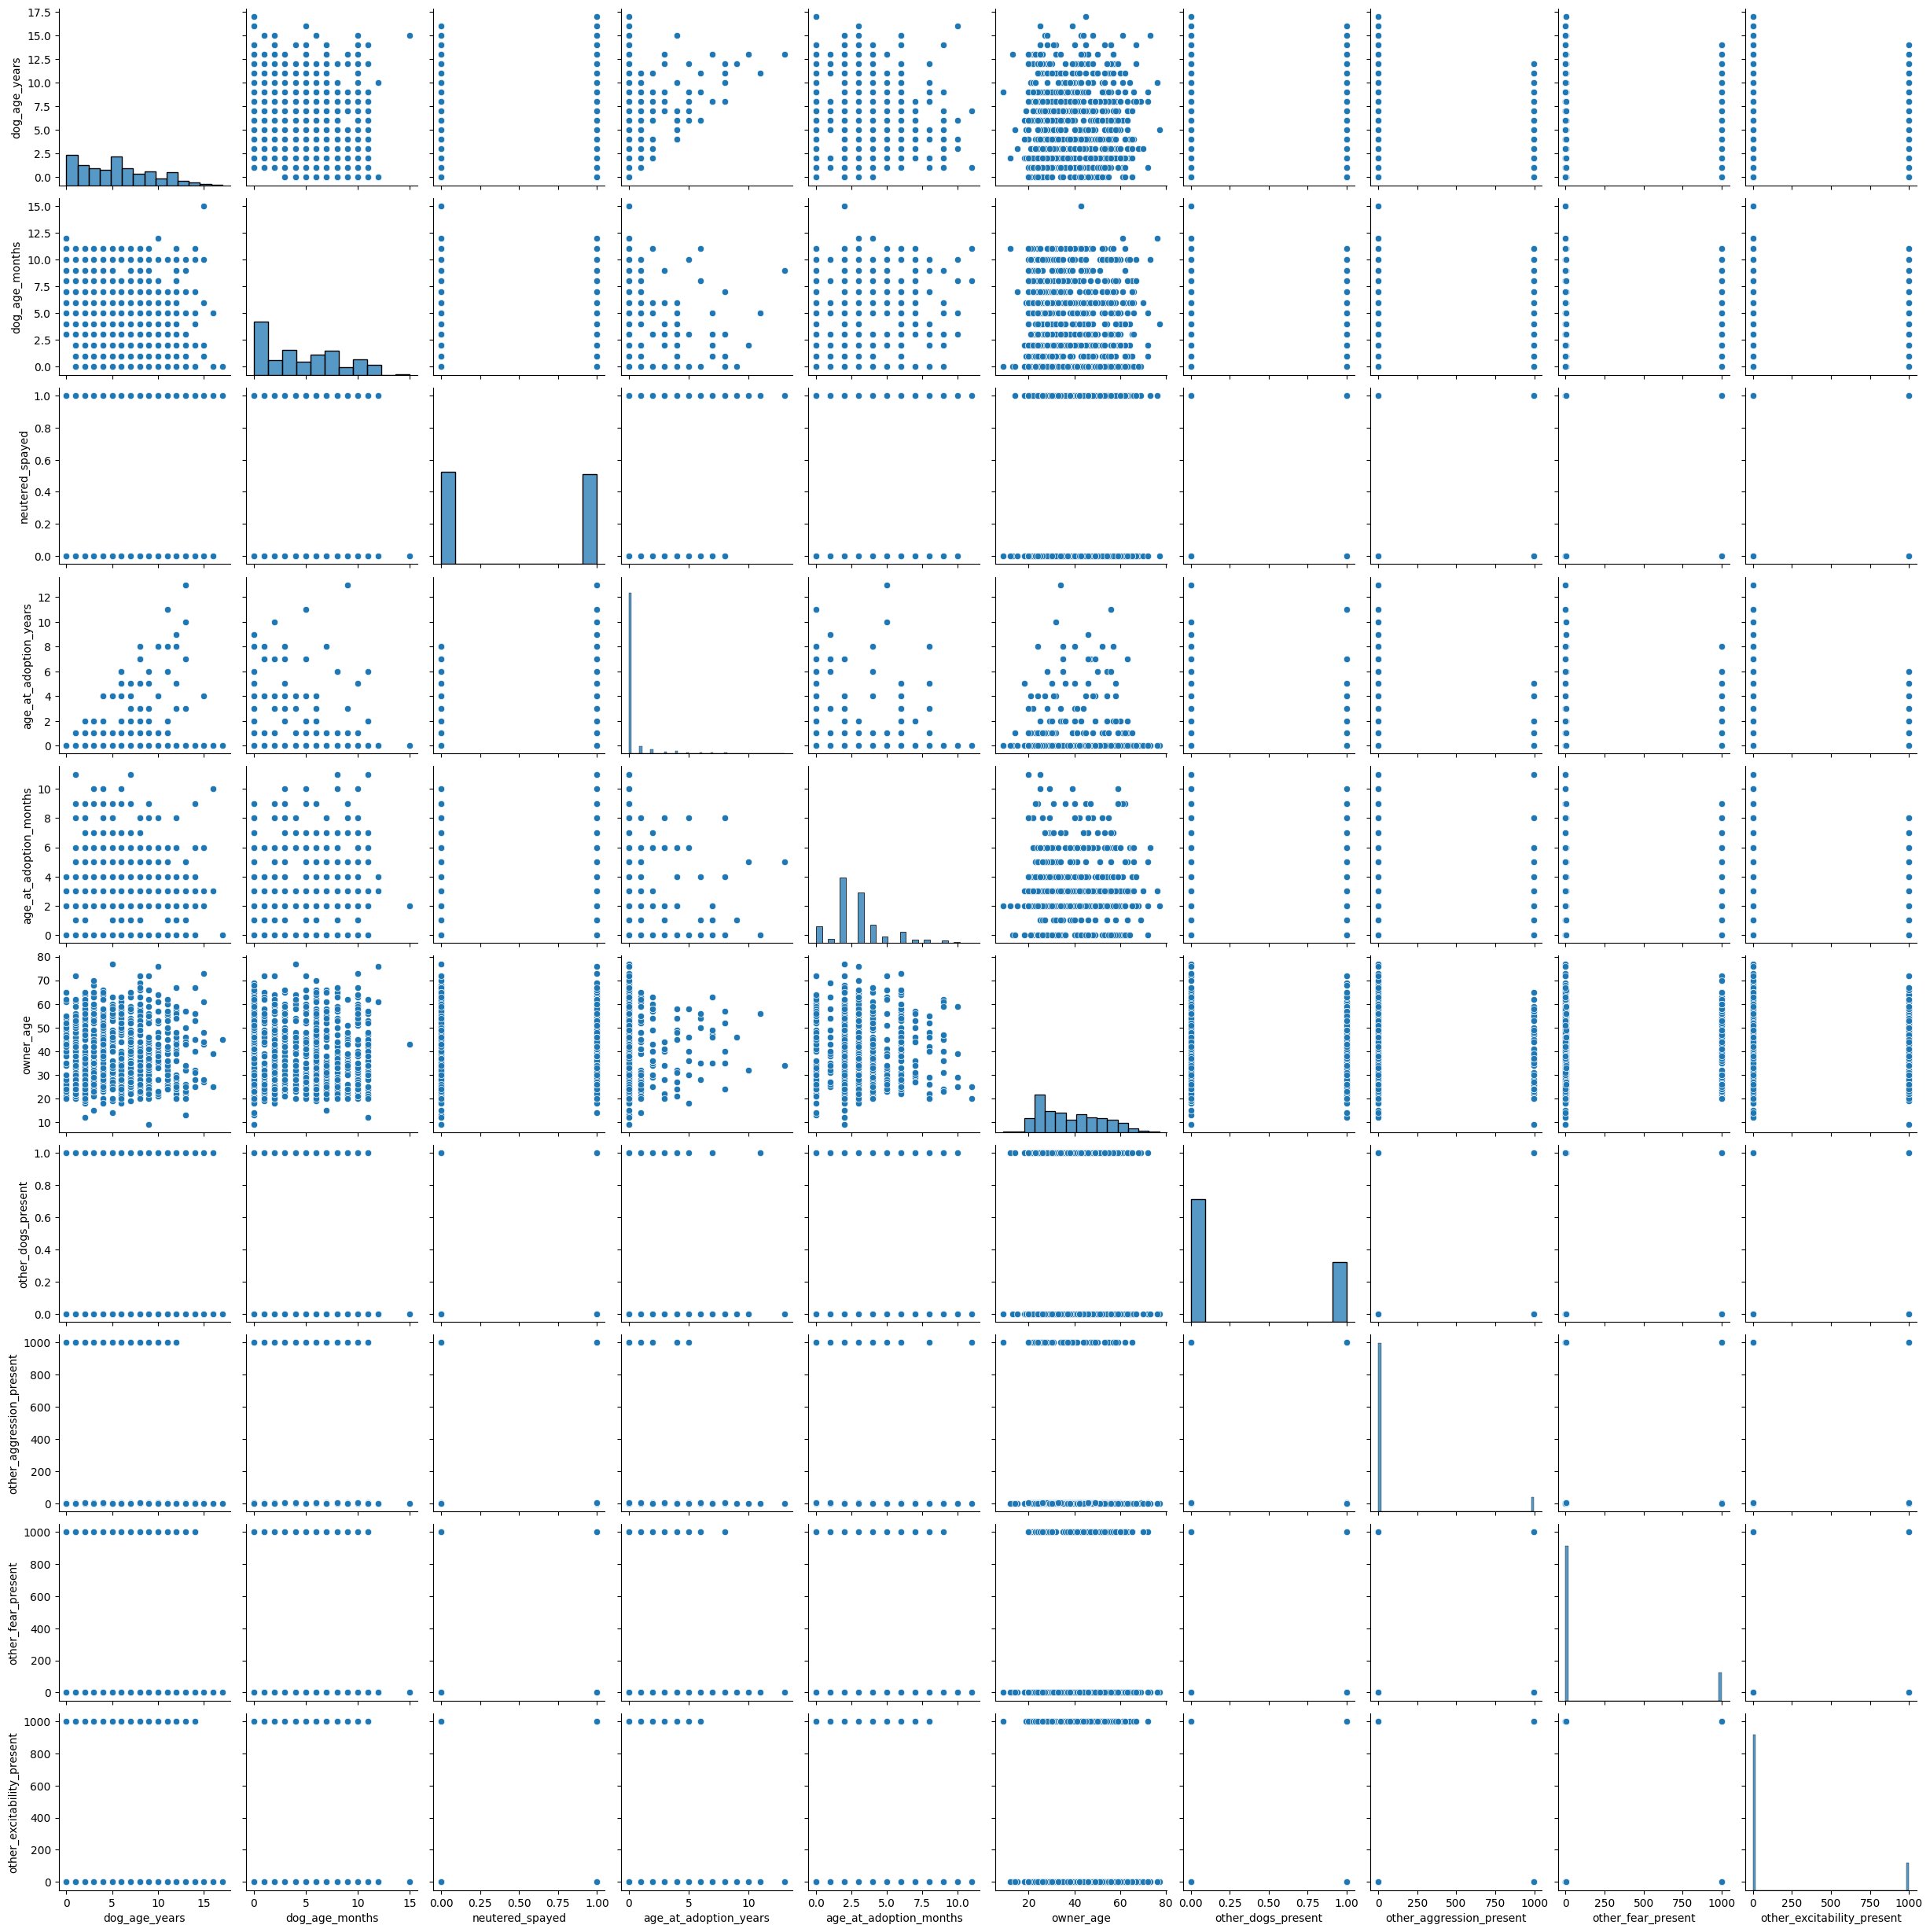

In [32]:
sns.pairplot(data=df_cbarq_encoded[['dog_age_years',
 'dog_age_months',
 'breed',
 'neutered_spayed',
 'age_at_adoption_years',
 'age_at_adoption_months',
 'owner_age',
 'owner_profession',
 'other_dogs_present', 
 'other_aggression_present', 
 'other_fear_present', 
 'other_excitability_present']])

plt.show()

In [33]:
breeds = df_cbarq_encoded['breed'].value_counts()

In [34]:
breeds.index = breeds.index.str.lower()
breeds.index = breeds.index.str.replace(' ', '_')
breeds.index = breeds.index.str.replace('-', '_')
breeds.index = breeds.index.str.replace('/', '_')
breeds.index = breeds.index.str.replace('(', '')
breeds.index = breeds.index.str.replace(')', '')
breeds.index = breeds.index.str.replace('.', '')

In [35]:
breeds.index

Index(['incrocio___meticcio', 'labrador_retriever', 'golden_retriever',
       'border_collie', 'jack_russel_terrier', 'pastore_tedesco',
       'american_staffordshire_terrier', 'altro', 'cocker_spaniel_inglese',
       'australian_shepherd', 'boxer', 'bouledogue_francese',
       'cavalier_king_charles_spaniel', 'bulldog', 'maltese', 'siberian_husky',
       'barbone_nano', 'cane_da_lupo_cecoslovacco', 'pinscher',
       'setter_inglese', 'cane_corso', 'chihuahua_a_pelo_corto',
       'yorkshire_terrier', 'weimaraner_a_pelo_corto', 'akita', 'rottweiler',
       'american_pitbull_terrier', 'pastore_maremmano_abruzzese',
       'bracco_italiano', 'lagotto_romagnolo', 'pinscher_nano',
       'galgo_espanol', 'barbone_toy', 'hovawart', 'bovaro_del_bernese',
       'bracco_ungherese_a_pelo_corto', 'bassotto_tedesco_nano_a_pelo_corto',
       'shih_tzu', 'bassotto_tedesco_standard_a_pelo_corto', 'boston_terrier',
       'dobermann', 'pastore_scozzese_shetland', 'alaskan_malamute',
       '

In [36]:
BREED_GROUP = {
  "incrocio___meticcio": "mixed",
  "altro": "other",

  # herding
  "border_collie": "herding",
  "pastore_tedesco": "herding",
  "australian_shepherd": "herding",
  "pastore_scozzese_shetland": "herding",
  "pastore_australiano_kelpie": "herding",
  "pastore_maremmano_abruzzese": "herding",
  "pastore_belga_malinois": "herding",
  "pastore_belga_groenendael": "herding",
  "pastore_belga_tervueren": "herding",
  "cane_da_pastore_scozzese_a_pelo_lungo": "herding",
  "welsh_corgi_cardigan": "herding",

  # gundog
  "labrador_retriever": "gundog",
  "golden_retriever": "gundog",
  "cocker_spaniel_inglese": "gundog",
  "cocker_americano": "gundog",
  "setter_inglese": "gundog",
  "setter_irlandese": "gundog",
  "pointer_inglese": "gundog",
  "springer_spaniel_inglese": "gundog",
  "weimaraner_a_pelo_corto": "gundog",
  "bracco_italiano": "gundog",
  "bracco_ungherese_a_pelo_corto": "gundog",
  "epagneul_breton": "gundog",
  "flat_coated_retriever": "gundog",
  "lagotto_romagnolo": "gundog",

  # terrier
  "jack_russel_terrier": "terrier",
  "parson_jack_russel_terrier": "terrier",
  "border_terrier": "terrier",
  "yorkshire_terrier": "terrier",
  "boston_terrier": "terrier",
  "staffordshire_bull_terrier": "terrier",

  # molosser
  "boxer": "molosser",
  "bulldog": "molosser",
  "bouledogue_francese": "molosser",
  "cane_corso": "molosser",
  "rottweiler": "molosser",
  "dobermann": "molosser",
  "dogo_argentino": "molosser",
  "alano": "molosser",
  "american_staffordshire_terrier": "molosser",
  "american_pitbull_terrier": "molosser",

  # spitz / nordic
  "siberian_husky": "spitz_nordic",
  "alaskan_malamute": "spitz_nordic",
  "samoiedo": "spitz_nordic",
  "akita": "spitz_nordic",
  "akita_americano_grande_cane_giapponese": "spitz_nordic",
  "shiba_inu": "spitz_nordic",
  "spitz_tedesco_nano": "spitz_nordic",
  "volpino_italiano": "spitz_nordic",
  "eurasier": "spitz_nordic",
  "cane_da_lupo_cecoslovacco": "spitz_nordic",
  "laika_russo_europeo": "spitz_nordic",

  # scenthound
  "beagle": "scenthound",
  "beagle_harrier": "scenthound",
  "bloodhound_chien_de_saint_hubert": "scenthound",
  "segugio_italiano_a_pelo_raso": "scenthound",
  "griffon_bleu_de_gascogne": "scenthound",
  "bassotto_tedesco_nano_a_pelo_corto": "scenthound",
  "bassotto_tedesco_standard_a_pelo_corto": "scenthound",
  "bassotto_tedesco_kaninchen_a_pelo_corto": "scenthound",
  "bassotto_tedesco_nano_a_pelo_duro": "scenthound",
  "bassotto_tedesco_standard_a_pelo_duro": "scenthound",

  # sighthound
  "whippet": "sighthound",
  "galgo_espanol": "sighthound",
  "piccolo_levriero_italiano": "sighthound",
  "cirneco_dell’etna": "sighthound",

  # companion / toy
  "maltese": "companion_toy",
  "chihuahua_a_pelo_corto": "companion_toy",
  "chihuahua_a_pelo_lungo": "companion_toy",
  "shih_tzu": "companion_toy",
  "cavalier_king_charles_spaniel": "companion_toy",
  "bichon_a_poil_frise": "companion_toy",
  "barbone_nano": "companion_toy",
  "barbone_toy": "companion_toy",
  "barbone_media_mole": "companion_toy",
  "pinscher_nano": "companion_toy",

  # working
  "hovawart": "working",
  "bovaro_del_bernese": "working",
  "terranova": "working",
  "rhodesian_ridgeback": "working",
  "basenji": "working",

  # pinscher / schnauzer
  "pinscher": "pinscher_schnauzer",
  "schnauzer_nano_zwergschnauzer": "pinscher_schnauzer",
  "schnauzer_medio": "pinscher_schnauzer",
}

BRACHYCEPHALIC_BREEDS = {
  "bulldog",
  "bouledogue_francese",
  "boston_terrier",
  "boxer",
  "cavalier_king_charles_spaniel",
  "shih_tzu",
}

def normalize_breed(s: str) -> str:
    return (
        s.lower()
        .replace(" ", "_")
        .replace("-", "_")
        .replace("/", "_")
        .replace("(", "")
        .replace(")", "")
        .replace(".", "")
    )

df_cbarq_encoded["breed_norm"] = df_cbarq_encoded["breed"].map(normalize_breed)
df_cbarq_encoded["breed_group"] = df_cbarq_encoded["breed_norm"].map(BREED_GROUP).fillna("other")
df_cbarq_encoded["is_mixed"] = (df_cbarq_encoded["breed_group"] == "mixed").astype("int8")
df_cbarq_encoded["is_brachycephalic"] = df_cbarq_encoded["breed_norm"].isin(BRACHYCEPHALIC_BREEDS).astype("int8")

/var/folders/3h/rqpyq0rd7qz5c8g6flkfykh80000gn/T/ipykernel_46091/3008395901.py:130: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cbarq_encoded["breed_norm"] = df_cbarq_encoded["breed"].map(normalize_breed)
/var/folders/3h/rqpyq0rd7qz5c8g6flkfykh80000gn/T/ipykernel_46091/3008395901.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cbarq_encoded["breed_group"] = df_cbarq_encoded["breed_norm"].map(BREED_GROUP).fillna("other")
/var/folders/3h/rqpyq0rd7qz5c8g6flkfykh80000gn/T/ipykernel_46091/3008395901.py:132: PerformanceW

In [37]:
top_breeds = df_cbarq_encoded["breed_norm"].value_counts().head(10).index
df_cbarq_encoded["breed_top"] = np.where(
    df_cbarq_encoded["breed_norm"].isin(top_breeds),
    df_cbarq_encoded["breed_norm"],
    "other_rare",
)
# Использовать breed_group + breed_top (11–12 категорий)

/var/folders/3h/rqpyq0rd7qz5c8g6flkfykh80000gn/T/ipykernel_46091/3705524845.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cbarq_encoded["breed_top"] = np.where(


In [38]:
df_cbarq_clean = df_cbarq_encoded.copy()

In [39]:
df_cbarq_clean = pd.get_dummies(df_cbarq_clean, columns=['breed_top', 'breed_group'], dtype=int)


In [40]:
df_cbarq_clean.drop(columns=['breed', 'owner_profession'], inplace=True)

In [41]:
df_cbarq_clean.drop(columns=['breed_norm'], inplace=True)

### Шаг 1. Очистка item-level ответов C-BARQ

- `999` → `NaN` (не наблюдалось / не применимо)
- значения вне 0–4 → `NaN` (артефакты ввода, напр. `803` в битых строках)

In [42]:
NA_SENTINEL = 999
VALID_MIN, VALID_MAX = 0, 4


def clean_questions(df, question_cols=None, inplace=False):
    """Очистка ответов C-BARQ: 999→NaN, валидный диапазон 0–4."""
    out = df if inplace else df.copy()
    if question_cols is None:
        question_cols = [c for c in out.columns if c.startswith("question_")]

    out[question_cols] = out[question_cols].apply(pd.to_numeric, errors="coerce")
    out[question_cols] = out[question_cols].replace(NA_SENTINEL, np.nan)

    invalid = out[question_cols].notna() & (
        (out[question_cols] < VALID_MIN) | (out[question_cols] > VALID_MAX)
    )
    out[question_cols] = out[question_cols].mask(invalid)

    return out




In [43]:
question_cols = [c for c in df_cbarq_clean.columns if c.startswith("question_")]
na_before = (df_cbarq_clean[question_cols] == NA_SENTINEL).sum().sum()
na_before

np.int64(2574)

In [44]:
numeric_questions = df_cbarq_clean[question_cols].apply(pd.to_numeric, errors="coerce")
out_of_range_before = (
    numeric_questions.notna()
    & ((numeric_questions < VALID_MIN) | (numeric_questions > VALID_MAX))
).sum().sum()



In [45]:
df_cbarq_clean = clean_questions(df_cbarq_clean)

print(f"999 replaced: {na_before}")
print(f"out-of-range → NaN: {out_of_range_before}")
print(f"remaining 999: {(df_cbarq_clean[question_cols] == NA_SENTINEL).sum().sum()}")
print(f"value range: {df_cbarq_clean[question_cols].min().min():.0f} – {df_cbarq_clean[question_cols].max().max():.0f}")
print(f"NaN share: {df_cbarq_clean[question_cols].isna().mean().mean():.1%}")

999 replaced: 2574
out-of-range → NaN: 2574
remaining 999: 0
value range: 0 – 4
NaN share: 3.4%


### Шаг 2. Reverse-coding для trainability (Q5–Q7)

Пункты с негативной формулировкой («медленно учится», «легко отвлекается») инвертируются: `4 - value`, чтобы все 8 пунктов trainability измеряли одно направление (выше = лучше послушание).

- Q5 — медленно реагирует на коррекцию
- Q6 — медленно учится
- Q7 — легко отвлекается

Q1–Q4 и Q8 не инвертируются.

In [46]:
TRAINABILITY_POSITIVE_ITEMS = [f"question_{i:03d}" for i in range(1, 5)] + ["question_008"]
TRAINABILITY_REVERSE_ITEMS = ["question_005", "question_006", "question_007"]
TRAINABILITY_ALL_ITEMS = TRAINABILITY_POSITIVE_ITEMS + TRAINABILITY_REVERSE_ITEMS


def reverse_trainability_items(df, inplace=False):
    """Инвертировать негативные пункты trainability: x → 4 - x."""
    out = df if inplace else df.copy()
    for col in TRAINABILITY_REVERSE_ITEMS:
        if col not in out.columns:
            continue
        mask = out[col].notna()
        out.loc[mask, col] = VALID_MAX - out.loc[mask, col]
    return out


def trainability_corr_matrix(df, items, label):
    """Средняя попарная корреляция внутри домена trainability."""
    sub = df[items].dropna(how="any")
    if len(sub) < 10:
        return pd.DataFrame(), np.nan
    corr = sub.corr()
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    mean_r = corr.where(mask).stack().mean()
    print(f"{label}: n={len(sub)}, mean pairwise r={mean_r:.3f}")
    return corr, mean_r


# Сохраняем копию до reverse для проверки
df_before_reverse = df_cbarq_clean.copy()

# Корреляции до reverse (смешанное направление пунктов)
corr_before, r_before = trainability_corr_matrix(
    df_before_reverse, TRAINABILITY_ALL_ITEMS, "Before reverse"
)
display(corr_before.round(2))

# Применяем reverse-coding
df_cbarq_clean = reverse_trainability_items(df_cbarq_clean)

# После reverse: все пункты кодированы в направлении «выше = лучше trainability»
corr_after, r_after = trainability_corr_matrix(
    df_cbarq_clean, TRAINABILITY_ALL_ITEMS, "After reverse"
)
display(corr_after.round(2))

# Контроль: r(Q1, Q5) должен сменить знак (преобразование x → 4−x)
r_q1_q5_before = df_before_reverse[["question_001", "question_005"]].dropna().corr().iloc[0, 1]
r_q1_q5_after = df_cbarq_clean[["question_001", "question_005"]].dropna().corr().iloc[0, 1]
print(f"r(Q1, Q5): {r_q1_q5_before:.3f} → {r_q1_q5_after:.3f} (знак должен инвертироваться)")

# Контроль: Q5–Q7 до/после
for col in TRAINABILITY_REVERSE_ITEMS:
    before = df_before_reverse[col].dropna()
    after = df_cbarq_clean.loc[before.index, col]
    print(
        f"{col}: mean {before.mean():.2f} → {after.mean():.2f}, "
        f"r(before, after)={before.corr(after):.3f} (ожидается −1)"
    )

Before reverse: n=655, mean pairwise r=0.223


,question_001,question_002,question_003,question_004,question_008,question_005,question_006,question_007
question_001,1.00,0.20,0.30,0.29,0.15,0.32,0.20,0.34
question_002,0.20,1.00,0.40,0.23,0.22,0.14,0.33,0.13
question_003,0.30,0.40,1.00,0.22,0.12,0.25,0.35,0.20
question_004,0.29,0.23,0.22,1.00,0.20,0.18,0.27,0.19
question_008,0.15,0.22,0.12,0.20,1.00,0.03,0.20,0.02
question_005,0.32,0.14,0.25,0.18,0.03,1.00,0.29,0.32
question_006,0.20,0.33,0.35,0.27,0.20,0.29,1.00,0.16
question_007,0.34,0.13,0.20,0.19,0.02,0.32,0.16,1.00


After reverse: n=655, mean pairwise r=-0.002


,question_001,question_002,question_003,question_004,question_008,question_005,question_006,question_007
question_001,1.00,0.20,0.30,0.29,0.15,-0.32,-0.20,-0.34
question_002,0.20,1.00,0.40,0.23,0.22,-0.14,-0.33,-0.13
question_003,0.30,0.40,1.00,0.22,0.12,-0.25,-0.35,-0.20
question_004,0.29,0.23,0.22,1.00,0.20,-0.18,-0.27,-0.19
question_008,0.15,0.22,0.12,0.20,1.00,-0.03,-0.20,-0.02
question_005,-0.32,-0.14,-0.25,-0.18,-0.03,1.00,0.29,0.32
question_006,-0.20,-0.33,-0.35,-0.27,-0.20,0.29,1.00,0.16
question_007,-0.34,-0.13,-0.20,-0.19,-0.02,0.32,0.16,1.00


r(Q1, Q5): 0.302 → -0.302 (знак должен инвертироваться)
question_005: mean 1.91 → 2.09, r(before, after)=-1.000 (ожидается −1)
question_006: mean 1.20 → 2.80, r(before, after)=-1.000 (ожидается −1)
question_007: mean 2.50 → 1.50, r(before, after)=-1.000 (ожидается −1)


### Шаг 3. Агрегация item → domain mean

Сырые ответы (`question_*`) сворачиваются в **13 доменных шкал C-BARQ** по среднему `mean(skipna)` — стандартный способ scoring.

- Домен считается, если ответлен ≥ `MIN_ITEMS` пунктов из домена

In [47]:
DOMAIN_ITEMS = {
    "trainability": [f"question_{i:03d}" for i in range(1, 9)],
    "stranger_directed_aggression": [
        "question_010", "question_011", "question_015", "question_016", "question_021", "question_028",
    ],
    "owner_directed_aggression": [
        "question_009", "question_013", "question_017", "question_019", "question_030", "question_031",
    ],
    "dog_directed_aggression": ["question_023", "question_024", "question_029"],
    "stranger_directed_fear": ["question_036", "question_037", "question_039", "question_040"],
    "nonsocial_fear": [
        "question_038", "question_041", "question_042", "question_044", "question_047", "question_048",
    ],
    "dog_directed_fear": ["question_045", "question_046"],
    "touch_sensitivity": ["question_049", "question_050", "question_051"],
    "separation_related": [f"question_{i:03d}" for i in range(54, 62)],
    "excitability": [f"question_{i:03d}" for i in range(62, 68)],
    "attachment": [f"question_{i:03d}" for i in range(68, 74)],
    "chasing": ["question_074", "question_075", "question_076"],
    "energy": ["question_090", "question_091", "question_092"],
}

MIN_ITEMS = 1


def to_domain_scores(df, domain_items=DOMAIN_ITEMS, min_items=MIN_ITEMS):
    """Агрегировать item-level ответы в доменные шкалы C-BARQ."""
    scores = {}
    coverage = {}
    for name, items in domain_items.items():
        items = [i for i in items if i in df.columns]
        if not items:
            scores[name] = pd.Series(np.nan, index=df.index)
            coverage[name] = pd.Series(np.nan, index=df.index)
            continue
        sub = df[items]
        n_valid = sub.notna().sum(axis=1)
        mean = sub.mean(axis=1, skipna=True)
        scores[name] = mean.where(n_valid >= min_items)
        coverage[name] = n_valid / len(items)
    return pd.DataFrame(scores), pd.DataFrame(coverage)


df_domains, df_domain_coverage = to_domain_scores(df_cbarq_clean)

print(f"rows: {len(df_domains)}, domains: {df_domains.shape[1]}")
print(f"domain NaN rate: {df_domains.isna().mean().mean():.2%}")
print(f"rows all domains complete: {(~df_domains.isna().any(axis=1)).mean():.1%}")
print("\nPer-domain missing (score undefined):")
display(df_domains.isna().mean().sort_values().to_frame("nan_rate").round(3))
print("\nDomain score summary:")
display(df_domains.describe().round(2))

rows: 800, domains: 13
domain NaN rate: 0.30%
rows all domains complete: 96.9%

Per-domain missing (score undefined):


,nan_rate
trainability,0.000
stranger_directed_aggression,0.000
owner_directed_aggression,0.000
nonsocial_fear,0.000
separation_related,0.000
excitability,0.000
stranger_directed_fear,0.001
touch_sensitivity,0.001
attachment,0.001
energy,0.001



Domain score summary:


,trainability,stranger_directed_aggression,owner_directed_aggression,dog_directed_aggression,stranger_directed_fear,nonsocial_fear,dog_directed_fear,touch_sensitivity,separation_related,excitability,attachment,chasing,energy
count,800.00,800.00,800.00,794.00,799.00,800.00,786.00,799.00,800.00,800.00,799.00,793.00,799.00
mean,1.47,0.44,0.19,1.33,0.63,1.04,0.81,0.63,0.61,2.04,2.42,2.27,1.68
std,0.40,0.64,0.41,1.01,0.89,0.72,0.99,0.76,0.60,0.76,0.81,1.29,0.90
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.25,0.00,0.00,0.67,0.00,0.50,0.00,0.00,0.12,1.50,1.83,1.33,1.00
50%,1.50,0.17,0.00,1.33,0.25,1.00,0.50,0.33,0.50,2.00,2.50,2.33,1.67
75%,1.62,0.67,0.17,2.00,1.00,1.50,1.00,1.00,0.88,2.60,3.00,3.33,2.33
max,3.25,4.00,3.33,4.00,4.00,4.00,4.00,4.00,3.75,4.00,4.00,4.00,4.00


### Шаг 4. Фильтр строк

Убираем собак с недостаточным покрытием доменных шкал — строки, где заполнено < `MIN_DOMAINS` из 13 доменов. Индексы `df_cbarq_clean` синхронизируются с `df_domains`.

MIN_DOMAINS=13: kept 775 / 800 (96.9%), dropped 25


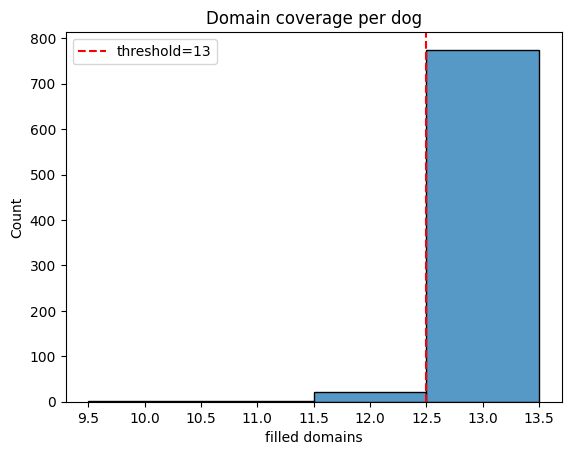


Dropped rows — missing domains (count across dropped):


,n_rows
dog_directed_fear,14
chasing,7
dog_directed_aggression,6
stranger_directed_fear,1
touch_sensitivity,1
attachment,1
energy,1
trainability,0
stranger_directed_aggression,0
owner_directed_aggression,0



Dropped rows detail:


,n_domains_filled,mean_coverage
759,10,0.769231
708,10,0.602564
707,11,0.794872
306,11,0.692308
123,12,0.766026
771,12,0.817308
726,12,0.887821
697,12,0.810897
674,12,0.923077
651,12,0.836538



After filter: 775 rows, domain NaN rate: 0.00%
rows all domains complete: 100.0%


In [48]:
MIN_DOMAINS = 13


def filter_rows_by_domains(df_domains, df_domain_coverage, df_meta, min_domains=MIN_DOMAINS):
    """Оставить строки с ≥ min_domains заполненными доменными шкалами."""
    n_domains_ok = df_domains.notna().sum(axis=1)
    keep = n_domains_ok >= min_domains
    dropped = ~keep

    report = {
        "total": len(df_domains),
        "kept": int(keep.sum()),
        "dropped": int(dropped.sum()),
        "kept_pct": keep.mean(),
    }
    return keep, n_domains_ok, report


keep_mask, n_domains_ok, filter_report = filter_rows_by_domains(
    df_domains, df_domain_coverage, df_cbarq_clean, min_domains=MIN_DOMAINS,
)

print(
    f"MIN_DOMAINS={MIN_DOMAINS}: kept {filter_report['kept']} / {filter_report['total']} "
    f"({filter_report['kept_pct']:.1%}), dropped {filter_report['dropped']}"
)

# Распределение числа заполненных доменов
sns.histplot(n_domains_ok, bins=range(0, df_domains.shape[1] + 2), discrete=True)
plt.axvline(MIN_DOMAINS - 0.5, color="red", linestyle="--", label=f"threshold={MIN_DOMAINS}")
plt.xlabel("filled domains")
plt.title("Domain coverage per dog")
plt.legend()
plt.show()

if filter_report["dropped"] > 0:
    dropped_idx = df_domains.index[~keep_mask]
    missing_domains = (~df_domains.loc[dropped_idx].notna()).sum()
    print("\nDropped rows — missing domains (count across dropped):")
    display(missing_domains.sort_values(ascending=False).to_frame("n_rows"))
    print("\nDropped rows detail:")
    display(
        pd.DataFrame({
            "n_domains_filled": n_domains_ok.loc[dropped_idx],
            "mean_coverage": df_domain_coverage.loc[dropped_idx].mean(axis=1),
        }).sort_values("n_domains_filled")
    )

# Применяем фильтр
df_domains = df_domains.loc[keep_mask].copy()
df_domain_coverage = df_domain_coverage.loc[keep_mask].copy()
df_cbarq_clean = df_cbarq_clean.loc[keep_mask].copy()

print(f"\nAfter filter: {len(df_domains)} rows, domain NaN rate: {df_domains.isna().mean().mean():.2%}")
print(f"rows all domains complete: {(~df_domains.isna().any(axis=1)).mean():.1%}")

In [50]:
for key, df in {
    "df_domains": df_domains,
    "df_cbarq_clean": df_cbarq_clean,
}.items():
    out = PATHS[key]
    out.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(out, index=False)
    print(
        f"Saved: {out} — "
        f"{df.shape[0]} rows, {df.shape[1]} columns"
    )


Saved: ../artifacts/csv/clean/df_domains.csv — 775 rows, 13 columns
Saved: ../artifacts/csv/clean/df_cbarq_clean.csv — 775 rows, 133 columns


In [51]:
out = PATHS["domain_items"]
out.parent.mkdir(parents=True, exist_ok=True)

with open(out, "w", encoding="utf-8") as f:
    json.dump(DOMAIN_ITEMS, f, indent=2, ensure_ascii=False)

print(f"Saved: {out} — {len(DOMAIN_ITEMS)} domains")

Saved: ../artifacts/json/domain_items.json — 13 domains
